# Propagacja długiej fali na stoku przybrzeżnym w modelu płytkiej wody

Celem projektu jest zbadanie, jak **nachylenie dna przybrzeżnego** wpływa na maksymalną wysokość fali docierającej do brzegu.

## Pytanie badawcze

> Jak zmienia się maksymalna wysokość powierzchni swobodnej w pobliżu brzegu w zależności od długości (a więc i kąta nachylenia) stoku przybrzeżnego dla tej samej fali początkowej propagującej się z obszaru głębokiej wody?


## Model fizyczny i wielkości

Oznaczenia:

- $\zeta(t;x,y)$ – wysokość swobodnej powierzchni względem geoidy ($z=0$),
- $b(x,y)$ – batymetria (głębokość dna mierzona dodatnio w dół od geoidy),
- $h(t;x,y) = \zeta + b$ – całkowita głębokość kolumny wody,
- $\vec{u} = [u, v]$ – składowe prędkości w kierunkach $x$ i $y$.

Równania wody płytkiej zapisujemy w postaci konserwatywnej dla $h$, $hu$, $hv$:
$$
\begin{cases}
  \partial_t h = -\nabla \cdot (\vec{u}h)\\\\
  \partial_t (hu) = -\nabla \cdot (\vec{u}hu) - gh\partial_x\zeta \\\\
  \partial_t (hv) = -\nabla \cdot (\vec{u}hv) - gh\partial_y\zeta \; ,
\end{cases}
$$
gdzie $g$ – przyspieszenie grawitacyjne.


In [19]:
import numpy as np
from matplotlib import pyplot

from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D


## Solwer równań wody płytkiej (PyMPDATA)

In [20]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, bathymetry: np.ndarray = None, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        self.bathymetry = bathymetry
        
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                
                
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

## Geometria dna i warunek początkowy

Rozpatrujemy prostokątną domenę numeryczną:

- kierunek $x$ – prostopadły do brzegu (od głębokiego morza w lewo do brzegu w prawo),
- kierunek $y$ – wzdłuż brzegu (batymetria nie zmienia się w funkcji $y$).

Dno zbudowane jest z trzech obszarów:

1. głębokie morze o stałej głębokości $h_\mathrm{deep}$,
2. stok przybrzeżny o zadanej długości (w ułamku długości domeny),
3. płytki brzeg o głębokości $h_\mathrm{shallow}$.

Zmieniamy **długość stoku** (a więc efektywnie jego nachylenie) i porównujemy maksymalną wysokość fali przy brzegu.

Sygnał emitowany na początku to gauss o środku w x=0

In [21]:
def make_sloping_beach_bathymetry(grid, *, h_deep=1.0, h_shallow=0.05, slope_length_frac=0.5):
    """Tworzy batymetrię: z lewej głębokie morze (h_deep),
    z prawej płytki brzeg (h_shallow) połączone liniowym stokiem
    o zadanej długości (w ułamku długości domeny)."""
    nx, ny = grid
    x = np.linspace(0.0, 1.0, nx).reshape(-1, 1)

    slope_length_frac = float(slope_length_frac)
    slope_length_frac = np.clip(slope_length_frac, 1e-3, 1.0)
    slope_start = 1.0 - slope_length_frac

    depth_1d = np.where(
        x <= slope_start,
        h_deep,
        h_deep - (h_deep - h_shallow) * np.clip((x - slope_start) / slope_length_frac, 0.0, 1.0)
    )

    bathymetry = np.repeat(depth_1d, ny, axis=1)
    return bathymetry


def make_initial_gaussian_bump(grid, bathymetry, *, amplitude=0.04, x0_frac=0, sigma_frac=0.05):
    """Warunek początkowy: wypukłość poziomu swobodnego w głębokiej wodzie,
    jednorodna wzdłuż brzegu (kierunek y)."""
    nx, ny = grid
    x = np.linspace(0.0, 1.0, nx).reshape(-1, 1)

    zeta_1d = amplitude * np.exp(-((x - x0_frac) ** 2) / (2.0 * sigma_frac ** 2))
    zeta = np.repeat(zeta_1d, ny, axis=1)

    h_initial = bathymetry + zeta
    return h_initial, zeta


def run_case(grid, slope_length_frac, *, nt, g, dt_over_dxy, outfreq, label=None):
    """Uruchamia pojedynczą symulację dla zadanej długości stoku."""
    bathymetry = make_sloping_beach_bathymetry(grid, slope_length_frac=slope_length_frac)
    h_initial, zeta0 = make_initial_gaussian_bump(grid, bathymetry)

    integrator = ShallowWaterEquationsIntegrator(h_initial=h_initial, bathymetry=bathymetry)
    output = integrator(nt=nt, g=g, dt_over_dxy=dt_over_dxy, outfreq=outfreq)

    return {
        "label": label or f"stok L={slope_length_frac}",
        "grid": grid,
        "slope_length_frac": slope_length_frac,
        "bathymetry": bathymetry,
        "h_initial": h_initial,
        "zeta0": zeta0,
        "output": output,
        "params": {
            "nt": nt,
            "g": g,
            "dt_over_dxy": dt_over_dxy,
            "outfreq": outfreq,
        },
    }


## Symulacje dla trzech nachyleń stoku

Porównamy trzy przypadki:

- A – stok łagodny (długi, 90% długości domeny),
- B – stok średni (50% długości domeny),
- C – stok stromy (20% długości domeny).

Wszystkie przypadki mają tę samą głębokość w głębokiej wodzie, tę samą głębokość przy brzegu
oraz identyczną falę początkową w głębokiej wodzie.


In [22]:
# parametry fizyczne i numeryczne
grid = (200, 40)            # (nx, ny)
skalicjusz = 5
g = 9.81
dt = 0.25/skalicjusz
dt_over_dxy = (dt, dt)
nt = 400*skalicjusz                     # liczba kroków czasowych
outfreq = 8                  # zapis co outfreq kroków

slopes = {
    "A: stok łagodny (L=0.9)": 0.9,
    "B: stok średni (L=0.5)": 0.5,
    "C: stok stromy (L=0.2)": 0.2,
}

cases = {}
for label, slope_len in slopes.items():
    print(f"Uruchamiam przypadek: {label}")
    cases[label] = run_case(
        grid, slope_len,
        nt=nt, g=g,
        dt_over_dxy=dt_over_dxy,
        outfreq=outfreq,
        label=label
    )


Uruchamiam przypadek: A: stok łagodny (L=0.9)
Uruchamiam przypadek: B: stok średni (L=0.5)
Uruchamiam przypadek: C: stok stromy (L=0.2)


## Diagnostyka: maksymalna wysokość fali przy brzegu

Za „brzeg” przyjmujemy kilka ostatnich komórek w kierunku $x$.
Dla każdej symulacji wyznaczamy w funkcji czasu:

- maksymalną wartość $\zeta = h - b$ w pobliżu brzegu,
- moment, w którym ta wartość jest największa.


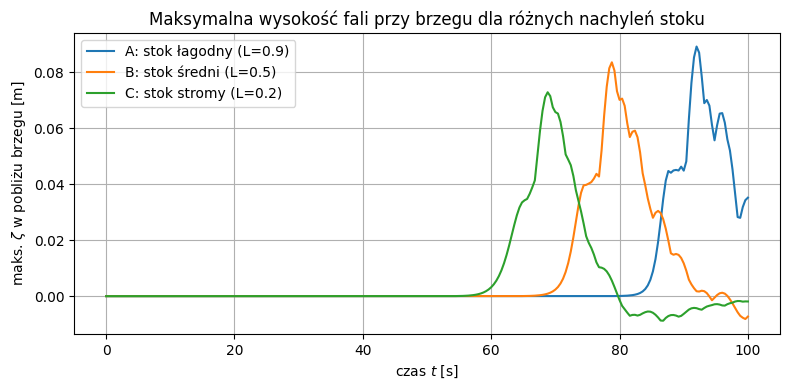

A: stok łagodny (L=0.9): maks. wysokość fali przy brzegu = 0.0892 m, dla której t = 92.00 s
B: stok średni (L=0.5): maks. wysokość fali przy brzegu = 0.0836 m, dla której t = 78.80 s
C: stok stromy (L=0.2): maks. wysokość fali przy brzegu = 0.0729 m, dla której t = 68.80 s


In [23]:
def max_shore_elevation_time_series(case, n_shore_cells=5):
    bath = case["bathymetry"]
    h_list = case["output"]["h"]
    nx, ny = bath.shape

    shore_slice = slice(nx - n_shore_cells, nx)
    series = []
    for h in h_list:
        zeta = h - bath
        series.append(np.max(zeta[shore_slice, :]))
    return np.array(series)


results_max = {}
pyplot.figure(figsize=(8, 4))

for label, case in cases.items():
    series = max_shore_elevation_time_series(case)
    results_max[label] = series

    dt_phys = case["params"]["dt_over_dxy"][0]
    outfreq = case["params"]["outfreq"]
    t = np.arange(len(series)) * outfreq * dt_phys

    pyplot.plot(t, series, label=label)

pyplot.xlabel(r"czas $t$ [s]")
pyplot.ylabel(r"maks. $\zeta$ w pobliżu brzegu [m]")
pyplot.title("Maksymalna wysokość fali przy brzegu dla różnych nachyleń stoku")
pyplot.legend()
pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()

for label, series in results_max.items():
    print(f"{label}: maks. wysokość fali przy brzegu = {series.max():.4f} m, dla której t = {np.argmax(series) * outfreq * dt_phys:.2f} s")


Analiza wykresu prowadzi do następujących spostrzeżeń:

1. Im bardziej stromy stok brzegu tym fala szybciej dochodzi do brzegu.

2. Im bardziej łagodny stok tym fala w ostaniej fazie piętrzy się wyżej.

Warto zaznaczyć, że pewna kanciastość tego wykresu może wynikać z dobranych kroków czasowych. Sprawdzono, że im dokładniejszą symulacje się wykona, tym wykres ten jest mniej kanciasty, ale wydłuża to diametralnie czas symulacji - wyżej widoczny wykres jest pewnym kompromisem dokładności do czasu symulacji.

Kolejna uwaga to fakt, że to co widzimy na wykresie dla danego przypadku po prawej stronie od najwyższeo punktu jest niefizyczne i nic nie znaczy. W symulacji, gdy fala dotrze do brzegu to się odbija tak jak od ściany, a w rzeczywistości po prostu zalewa ląd. Należy więc przymróżyć oko na ten fragment wykresu.

## Wizualizacja powierzchni swobodnej i batymetrii

Poniżej: animacja (plik animacja_3d_wireframe.gif) porównująca ewolucję powierzchni swobodnej dla wszystkich trzech przypadków (A, B, C).



Animacja obrazuje zarówno ułożenie dna, jak i propagacje fali. Przyglądając się można zaobserwować to co widać było na poprzednim wykresie.

Aby nie trzeba było odpalać programu, żeby obejrzeć animacje, wyeksportowane je do .gif i umieszczono w:

https://github.com/MUPAGH2025/2proszowski/tree/main/animacje

widnieje tam zarówno animacja 3d, jak i animacja przekroju poprzecznego


In [24]:
def create_3d_wireframe_animation(cases_dict, frames_to_show=None, frame_skip=10*skalicjusz):
    """
    Tworzy animację 3D wireframe dla wszystkich przypadków (A, B, C).
    """
    case_list = list(cases_dict.items())
    n_cases = len(case_list)
    
    if frames_to_show is None:
        frames_to_show = range(0, len(case_list[0][1]["output"]["h"]), frame_skip)
    
    # znajdź zakres dla osi z
    zeta_min, zeta_max = 0, 0
    for label, case in case_list:
        bathymetry = case["bathymetry"]
        for frame in frames_to_show:
            h = case["output"]["h"][frame]
            zeta = h - bathymetry
            zeta_min = min(zeta_min, zeta.min())
            zeta_max = max(zeta_max, zeta.max())
    
    zlim = (zeta_min - 0.02, zeta_max + 0.02)
    
    # utworzenie figury
    fig = pyplot.figure(figsize=(18, 7))
    
    axes = []
    wireframes = []
    contours = []
    titles = []
    
    for i, (label, case) in enumerate(case_list):
        ax = fig.add_subplot(1, n_cases, i+1, projection='3d')
        axes.append(ax)
        
        bathymetry = case["bathymetry"]
        h_init = case["output"]["h"][0]
        zeta_init = h_init - bathymetry
        
        xi, yi = np.indices(zeta_init.shape)
        
        # początkowy wireframe
        wireframe = ax.plot_wireframe(xi+.5, yi+.5, zeta_init, color='blue', linewidth=.5)
        wireframes.append(wireframe)
        
        # batymetria
        contour = ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0], cmap='terrain', alpha=0.6)
        contours.append(contour)
        
        # ustawienia
        ax.set(zlim=zlim, proj_type='ortho', zlabel=r"$\zeta$ [m]")
        
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.fill = False
            axis.pane.set_edgecolor('black')
            axis.pane.set_alpha(1)
        
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        
        title = ax.set_title(f"{label}\nt = 0.0 [s]")
        titles.append(title)
    
    def update(frame_idx):
        frame = list(frames_to_show)[frame_idx]
        
        for i, (label, case) in enumerate(case_list):
            bathymetry = case["bathymetry"]
            h = case["output"]["h"][frame]
            zeta = h - bathymetry
            
            xi, yi = np.indices(zeta.shape)
            
            # usuń stary wireframe
            wireframes[i].remove()
            
            # dodaj nowy wireframe
            wireframes[i] = axes[i].plot_wireframe(xi+.5, yi+.5, zeta, color='blue', linewidth=.5)
            
            # aktualizuj tytuł
            dt_phys = case["params"]["dt_over_dxy"][0]
            outfreq = case["params"]["outfreq"]
            t = frame * outfreq * dt_phys
            titles[i].set_text(f"{label}\nt = {t:.1f} [s]")
        
        return wireframes + titles
    
    pyplot.tight_layout()
    
    anim = FuncAnimation(fig, update, 
                        frames=len(list(frames_to_show)), 
                        interval=100, blit=False, repeat=True)
    
    return anim


# tworzenie animacji 3D
#``print("Tworzenie animacji 3D wireframe...")
#anim_3d = create_3d_wireframe_animation(cases, frame_skip=2*skalicjusz)

#anim_3d.save('animacja_3d_wireframe.gif', writer='pillow', fps=8, dpi=80)
# wyświetlenie animacji
#HTML(anim_3d.to_jshtml(fps=8, default_mode='loop'))

In [25]:

def create_comparison_animation(cases_dict, frames_to_show=None):
    """
    Tworzy animację porównującą wszystkie przypadki (A, B, C).
    Pokazuje przekroje 1D wzdłuż x oraz mapy 2D dla każdego przypadku.
    """
    # przygotowanie danych
    case_list = list(cases_dict.items())
    n_cases = len(case_list)
    
    # jeśli nie podano ramek, używamy wszystkich
    if frames_to_show is None:
        frames_to_show = range(len(case_list[0][1]["output"]["h"]))
    
    # figura: górny rząd - przekroje 1D, dolny rząd - mapy 2D
    fig = pyplot.figure(figsize=(16, 8))
    
    # przygotowanie podwykresów
    axes_1d = []
    axes_2d = []
    
    for i, (label, case) in enumerate(case_list):
        # górny rząd - przekroje 1D
        ax1d = pyplot.subplot(2, n_cases, i + 1)
        axes_1d.append(ax1d)
        
        # dolny rząd - mapy 2D
        ax2d = pyplot.subplot(2, n_cases, n_cases + i + 1)
        axes_2d.append(ax2d)
    
    # przygotowanie batymetrii i osi x
    nx = case_list[0][1]["bathymetry"].shape[0]
    ny = case_list[0][1]["bathymetry"].shape[1]
    x = np.arange(nx)
    y_index = ny // 2
    
    # znajdź zakres dla osi z (dla spójności między klatkami)
    zeta_min, zeta_max = 0, 0
    for label, case in case_list:
        bathymetry = case["bathymetry"]
        for frame in frames_to_show:
            h = case["output"]["h"][frame]
            zeta = h - bathymetry
            zeta_min = min(zeta_min, zeta.min())
            zeta_max = max(zeta_max, zeta.max())
    
    zeta_margin = (zeta_max - zeta_min) * 0.1
    
    # inicjalizacja
    lines_1d = []
    lines_bath = []
    images_2d = []
    colorbars = []
    damping_patches = []
    
    
    for i, (label, case) in enumerate(case_list):
        bathymetry = case["bathymetry"]
        
        # przekrój 1D
        ax1d = axes_1d[i]
        
        line_bath, = ax1d.plot(x, -bathymetry[:, y_index], 'k-', linewidth=1, alpha=0.5, label='dno')
        line, = ax1d.plot([], [], 'b-', linewidth=2, label=r'$\zeta$')
        ax1d.set_xlim(0, nx - 1)
        ax1d.set_ylim(zeta_min - zeta_margin, zeta_max + zeta_margin)
        ax1d.set_xlabel('x [m]')
        ax1d.set_ylabel(r'wysokość [m]')
        ax1d.set_title(label)
        ax1d.grid(True, alpha=0.3)
        ax1d.legend(loc='upper left', fontsize=8)
        lines_1d.append(line)
        lines_bath.append(line_bath)
        
        # mapa 2D
        ax2d = axes_2d[i]
        h_init = case["output"]["h"][0]
        zeta_init = h_init - bathymetry
        im = ax2d.imshow(zeta_init.T, origin='lower', aspect='auto', 
                         vmin=zeta_min, vmax=zeta_max, cmap='RdBu_r')
        
        ax2d.set_xlabel('x [m]')
        ax2d.set_ylabel('y [m]')
        cbar = pyplot.colorbar(im, ax=ax2d, fraction=0.046, pad=0.04)
        cbar.set_label(r'$\zeta$ [m]')
        images_2d.append(im)
        colorbars.append(cbar)
    
    time_text = fig.suptitle('', fontsize=14, fontweight='bold')
    
    def init():
        for line in lines_1d:
            line.set_data([], [])
        return lines_1d + images_2d + [time_text]
    
    def update(frame_idx):
        frame = list(frames_to_show)[frame_idx]
        
        for i, (label, case) in enumerate(case_list):
            bathymetry = case["bathymetry"]
            h = case["output"]["h"][frame]
            zeta = h - bathymetry
            
            # aktualizacja przekroju 1D
            lines_1d[i].set_data(x, zeta[:, y_index])
            
            # aktualizacja mapy 2D
            images_2d[i].set_data(zeta.T)
        
        # aktualizacja tytułu z czasem
        dt_phys = case_list[0][1]["params"]["dt_over_dxy"][0]
        outfreq = case_list[0][1]["params"]["outfreq"]
        t = frame * outfreq * dt_phys
        time_text.set_text(f'Czas: t = {t:.1f} (krok {frame})')
        
        return lines_1d + images_2d + [time_text]
    
    pyplot.tight_layout(rect=[0, 0, 1, 0.96])
    
    anim = FuncAnimation(fig, update, init_func=init,
                        frames=len(list(frames_to_show)), 
                        interval=100, blit=True, repeat=True)
    
    return anim

# tworzenie animacji dla wszystkich przypadków A, B, C
# print("Tworzenie animacji dla wszystkich przypadków...")
# anim = create_comparison_animation(cases)
# anim.save('animacja_comparison.gif', writer='pillow', fps=8, dpi=80)

# # wyświetlenie animacji
# HTML(anim.to_jshtml())

Powyższa animacja (plik animacja_comparison.gif) z kolei pokazuje przekrój poprzeczny fali wzdółż osi x oraz rzut na oś xy. 

Analizując przebieg fali można zawuażyć, że w miarę przebiegu, początkowy sygnał gaussa się odkształca. Dzieje się tak, ponieważ środek gaussa (punkt o najwyższej wysokości), mając większą prędkość goni początek fali. Co ciekawe, dla najwolniejszej propagacji (czyli dla łagodnego stoku), widać że wolniejszy tył gaussa się lekko odłącza od reszty fali w końcowej fazie. Tak samo dzieje się w rzeczywistości:  niższe części fali z powodu tarcia o dno mają mniejszą prędkość niż wyższe części. Rzeczywiste fale jednak są nieco grubsze niż te zasymulowane, dltego w symulacji ten tył prawie że się odłącza.

Warto jeszcze zaznaczyć, że w symulacji nie uwzględniono zjawiska załamywania się fali, które ma mijesce gdy stosunek wysokości fali nad wodą do wysokości fali pod wodą jest równy 10/13. Mimo wszystko ten fakt nie powinen wpłynąć na porównanie wysokości fali do stromości dna.

## Pole prędkości

Z danych modelu możemy odzyskać prędkość z gęstości pędu $hu$, $hv$:

$$
u = \frac{hu}{h}, \quad v = \frac{hv}{h}.
$$


In [26]:
def compute_velocity(case, frame, eps=1e-7):
    h = case["output"]["h"][frame]
    uh = case["output"]["uh"][frame]
    vh = case["output"]["vh"][frame]

    u = np.zeros_like(h)
    v = np.zeros_like(h)

    mask = h > eps
    np.divide(uh, h, out=u, where=mask)
    np.divide(vh, h, out=v, where=mask)
    return u, v


def compute_velocity_magnitude(case, frame, eps=1e-7):
    """Oblicza wielkość prędkości (magnitude) dla danej ramki."""
    u, v = compute_velocity(case, frame, eps)
    return np.sqrt(u**2 + v**2)




In [27]:
def find_max_velocity_frame(case, n_shore_cells=10):
    """Znajduje ramkę z maksymalną prędkością w pobliżu brzegu."""
    bathymetry = case["bathymetry"]
    nx, ny = bathymetry.shape
    
    shore_slice = slice(nx - n_shore_cells, nx)
    max_vel = 0
    max_frame = 0
    
    for frame_idx, h in enumerate(case["output"]["h"]):
        vel_mag = compute_velocity_magnitude(case, frame_idx)
        vel_at_shore = np.max(vel_mag[shore_slice, :])
        if vel_at_shore > max_vel:
            max_vel = vel_at_shore
            max_frame = frame_idx
    
    return max_frame, max_vel



# wypisanie informacji o momentach maksymalnej prędkości
print("\nMomenty maksymalnej prędkości:")
for label, case in cases.items():
    max_frame, max_vel = find_max_velocity_frame(case)
    dt_phys = case["params"]["dt_over_dxy"][0]
    outfreq = case["params"]["outfreq"]
    t = max_frame * outfreq * dt_phys
    print(f"{label}: t = {t:.1f} s (ramka {max_frame}), maks. prędkość = {max_vel:.3f} m/s")


Momenty maksymalnej prędkości:
A: stok łagodny (L=0.9): t = 89.6 s (ramka 224), maks. prędkość = 0.484 m/s
B: stok średni (L=0.5): t = 76.4 s (ramka 191), maks. prędkość = 0.406 m/s
C: stok stromy (L=0.2): t = 66.4 s (ramka 166), maks. prędkość = 0.274 m/s


## Analiza energii fali

Z wyników widać wyraźny trend: **stok łagodny (A) prowadzi do największej wysokości i prędkości fali przy brzegu**, co oznacza największą energię.

Całkowita energia fali w modelu płytkiej wody składa się z:

- **energii potencjalnej**: $E_p = \frac{1}{2}g\zeta^2$ (związanej z wypiętrzeniam powierzchni)
- **energii kinetycznej**: $E_k = \frac{1}{2}h|\vec{u}|^2$ (związanej z ruchem wody)

Stromy stok (C) powoduje szybszą dysypację energii przez gwałtowne zmiany głębokości, podczas gdy łagodny stok (A) pozwala fali na bardziej efektywne przeniesienie energii ku brzegowi, co prowadzi do wyższego run-up.



Wyniki potwierdzają mechanizm **shoalingu** (efekt mielizny):

1. **Stok łagodny (A)**: 
   - Fala stopniowo zwalnia na długim stoku
   - Energia jest efektywnie transformowana z energii kinetycznej w potencjalną
   - Długość fali maleje, amplituda rośnie
   - Mniejsze straty energii przez dysypację
   - **Największy run-up**

2. **Stok stromy (C)**:
   - Gwałtowna zmiana głębokości
   - Większe straty przez gwałtowne zmiany przepływu
   - **Najmniejszy run-up**



## Analiza zbieżności przy podwojeniu rozdzielczości przestrzennej i czasowej

Dla przypadku referencyjnego (stok średni) porównujemy dwa przebiegi:

- siatka „gruba”: $(n_x, n_y)$, krok czasowy $\Delta t$,
- siatka „gęsta”: $(2n_x, 2n_y)$, krok czasowy $\Delta t/2$, liczba kroków czasowych podwojona,

tak aby całkowity czas symulacji był ten sam i aby porównywać przebieg maksymalnej
wysokości fali przy brzegu w funkcji czasu.


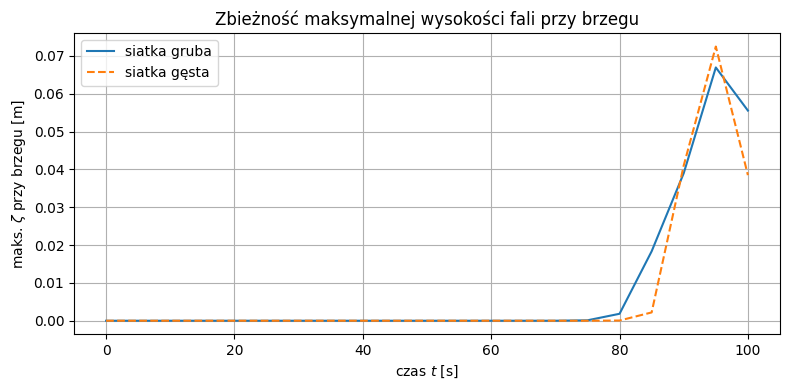

Maks. fala – siatka gruba: 0.0669
Maks. fala – siatka gęsta: 0.0725
Względna różnica maks. wysokości fali: 7.63%


In [28]:
# konfiguracja zbieżności – stok średni
slope_ref = 0.5

grid_coarse = (120, 40)
nowy_skalicjusz = 2
grid_fine = (grid_coarse[0] * nowy_skalicjusz, grid_coarse[1] * nowy_skalicjusz)
dt_coarse = 0.25
dt_fine = dt_coarse / nowy_skalicjusz

nt_coarse = 200
nt_fine = nowy_skalicjusz**2 * nt_coarse

outfreq_coarse = 10
outfreq_fine = nowy_skalicjusz**2 * outfreq_coarse  

case_coarse = run_case(
    grid_coarse, slope_ref,
    nt=nt_coarse, g=g,
    dt_over_dxy=(dt_coarse, dt_coarse),
    outfreq=outfreq_coarse,
    label="siatka gruba"
)

case_fine = run_case(
    grid_fine, slope_ref,
    nt=nt_fine, g=g,
    dt_over_dxy=(dt_fine, dt_fine),
    outfreq=outfreq_fine,
    label="siatka gęsta"
)

series_coarse = max_shore_elevation_time_series(case_coarse, n_shore_cells=5)
series_fine = max_shore_elevation_time_series(case_fine, n_shore_cells=5)

dt_phys = dt_fine
t = np.arange(len(series_fine)) * outfreq_fine * dt_phys

pyplot.figure(figsize=(8, 4))
pyplot.plot(t, series_coarse, label="siatka gruba")
pyplot.plot(t, series_fine, label="siatka gęsta", linestyle="--")
pyplot.xlabel(r"czas $t$ [s]")
pyplot.ylabel(r"maks. $\zeta$ przy brzegu [m]")
pyplot.title("Zbieżność maksymalnej wysokości fali przy brzegu")
pyplot.grid(True)
pyplot.legend()
pyplot.tight_layout()
pyplot.show()

max_coarse = series_coarse.max()
max_fine = series_fine.max()
rel_diff = abs(max_fine - max_coarse) / max_fine

print(f"Maks. fala – siatka gruba: {max_coarse:.4f}")
print(f"Maks. fala – siatka gęsta: {max_fine:.4f}")
print(f"Względna różnica maks. wysokości fali: {100 * rel_diff:.2f}%")


Jak widać różnica w wyniku jest widoczna po podwojeniu rozdzielczości czasowej i przestrzennej, dlatego bardzo istone jest wypośrodkowanie pomiędzy dokładnością wyniku a czasem symulacji.

Przeprowadzono także obliczenia dla 4 razy większęj rozdzielczości i 10 razy większej rozdzielczości (dla 4 obliczenia wykonywały się 1:30, a dla 10 ponad 38 minut!). Za każdym zwiększeniem rozdzielczości obserwowano zwężenie wykresu oraz ciągle pewne fluktuacje maksymalnej wysokości, jednak nie zauważono żadnego błędu krytycznego symulacji.

### Uwagi dodatkowe

W projekcie podjęto działanie aby sprawdzić jak propaguje się fala dla różnych kształtów brzegu (sprawdzono dla brzegu skośnego, o kształcie gaussa i kształcie sinusa). Symulacja jedank nie była zadowalająca. Jednak na podstawie obliczeń zawartych w oryginalnym projekcie można sobie wyobrazić jak taka fala, dla nieregularnego kształtu brzegu mogłaby wyglądać.